# 1. Purpose and timing

N22 applies the frozen realised–implied volatility structure to a chronology-safe historical application panel. It does not select models or fit the downstream N24 correction model.

$$
A \rightarrow B \rightarrow C \rightarrow \mathrm{VALIDATION} \rightarrow \mathrm{TEST}.
$$

The completed pre-TEST N19 designs are applied retrospectively to earlier blocks. C is therefore a historical out-of-sample analogue conditional on the final frozen design, not a claim that those hyperparameters would have been selected in real time in 2012.

In [1]:
from pathlib import Path
import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display
PROJECT_DIR_OVERRIDE=None
PROJECT_DIR=Path(PROJECT_DIR_OVERRIDE).expanduser().resolve() if PROJECT_DIR_OVERRIDE is not None else Path.cwd().resolve()
PROCESSED=PROJECT_DIR/'Data'/'processed'; FIGURES=PROJECT_DIR/'figures'
if not PROCESSED.is_dir() or not FIGURES.is_dir(): raise RuntimeError(f'Run N22 from the canonical project root; got {PROJECT_DIR}')
UNLOCK_TEST_TARGETS=False
ACTIVE_THRESHOLD=0.95; MIN_MODEL_SUPPORT=3
FLEXIBLE_MODELS=('RF','GB','MLP','TRANSFORMER'); TARGETS=('R','I'); MAX_LAG=12
NEURAL_SEEDS=(19,119,219); BLOOMBERG_ALIGNMENT='BLOOMBERG_BGN_1700_TO_1659_SAME_MODEL_DAY'
PRIMARY_FAMILIES={'FOMC','US Employment','US CPI','BoJ','JPY National CPI','JPY GDP'}
RF_GRID={'RF_01':{'max_depth':8,'min_samples_leaf':5},'RF_02':{'max_depth':8,'min_samples_leaf':10},'RF_03':{'max_depth':None,'min_samples_leaf':5},'RF_04':{'max_depth':None,'min_samples_leaf':10}}
GB_GRID={'GB_01':{'n_estimators':200,'learning_rate':.03},'GB_02':{'n_estimators':200,'learning_rate':.05},'GB_03':{'n_estimators':400,'learning_rate':.03},'GB_04':{'n_estimators':400,'learning_rate':.05}}
MLP_GRID={'MLP_01':([32],1e-3),'MLP_02':([32],3e-4),'MLP_03':([32,16],1e-3),'MLP_04':([32,16],3e-4)}
TR_GRID={'TR_01':((16,2,32),1e-3),'TR_02':((16,2,32),3e-4),'TR_03':((24,4,48),1e-3),'TR_04':((24,4,48),3e-4)}
GRIDS={'RF':RF_GRID,'GB':GB_GRID,'MLP':MLP_GRID,'TRANSFORMER':TR_GRID}
RF_FIXED={'n_estimators':500,'max_features':.5,'criterion':'squared_error','bootstrap':True,'random_state':19,'n_jobs':-1}
GB_FIXED={'max_depth':2,'min_samples_leaf':10,'subsample':1.0,'loss':'squared_error','random_state':19}
CONFIG={'states':['Q','R','I'],'max_lag':12,'neural_seeds':NEURAL_SEEDS,'max_epochs':400,'patience':40,'min_delta':1e-5,'batch_size':64}
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); torch.set_num_threads(1)
if torch.cuda.is_available(): torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
print(f'PROJECT_DIR={PROJECT_DIR}; TEST targets locked={not UNLOCK_TEST_TARGETS}; device={DEVICE}')


PROJECT_DIR=C:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do; TEST targets locked=True; device=cuda


# 2. Frozen inputs and configuration

N22 reads frozen N16–N21 artefacts, retains the canonical alignment, and refits frozen specifications only.

In [2]:
files={'panel':'16_empirical_analysis_panel.csv','n16':'16_primary_specification.csv','n19':'19_selected_model_specifications.csv','n20':'20_api_ordinary_response_ratios.csv','n20spec':'20_api_specification.csv','events':'18_target_specific_event_mapping.csv','n21state':'21_application_state_panel.csv','n21cand':'21_hidden_event_candidate_days.csv','n21episodes':'21_hidden_event_episodes.csv','n21thr':'21_hidden_event_thresholds.csv','n21signal':'21_volatility_disagreement_signal.csv','n20meta':'20_api_run_metadata.csv','n20equivalence':'20_api_equivalence_summary.csv','n21meta':'21_run_metadata.csv','n21closure':'21_validation_closure_metadata.csv'}
missing=[x for x in files.values() if not (PROCESSED/x).is_file()]
if missing: raise FileNotFoundError(missing)
n16=pd.read_csv(PROCESSED/files['n16']); valid_n16=n16.loc[n16['iv_specification'].eq('WEEKDAY_NORM_IV') & n16['iv_column'].notna()].copy(); assert not valid_n16.empty and valid_n16['iv_column'].eq('iv_model_var').all(); spec16=valid_n16.iloc[-1]; IV_COLUMN=str(spec16['iv_column'])
panel=pd.read_csv(PROCESSED/files['panel'],parse_dates=['model_day']); specs=pd.read_csv(PROCESSED/files['n19'])
ratios=pd.read_csv(PROCESSED/files['n20'],parse_dates=['model_day','target_model_day']); events=pd.read_csv(PROCESSED/files['events'],parse_dates=['realised_model_day','implied_model_day','target_model_day'])
n21=pd.read_csv(PROCESSED/files['n21state'],parse_dates=['model_day','next_model_day']); n21_signal=pd.read_csv(PROCESSED/files['n21signal'],parse_dates=['model_day','previous_model_day']); n20_meta=pd.read_csv(PROCESSED/files['n20meta']); n20_equivalence=pd.read_csv(PROCESSED/files['n20equivalence']); n21_meta=pd.read_csv(PROCESSED/files['n21meta']); n21_closure=pd.read_csv(PROCESSED/files['n21closure']); candidates=pd.read_csv(PROCESSED/files['n21cand'],parse_dates=['realised_model_day','implied_reference_model_day']); episodes=pd.read_csv(PROCESSED/files['n21episodes'],parse_dates=['start_day','end_day','peak_day']); n20spec=pd.read_csv(PROCESSED/files['n20spec'])
assert {'model_day','sample_split','squared_return','realised_variance_ann_252',IV_COLUMN}.issubset(panel.columns)
assert panel.model_day.is_unique and panel.model_day.is_monotonic_increasing and set(panel.sample_split)=={'train','validation','test'}
assert set(ratios.sample_split.dropna())=={'validation','test'} and ratios['is_out_of_sample'].eq(True).all()
assert {'ordinary_background_forecast','ordinary_response_ratio','ratio_defined','equation_eligible'}.issubset(ratios.columns)
assert n20spec.loc[n20spec.item.eq('event_alignment_version'),'value'].iloc[0]==BLOOMBERG_ALIGNMENT
assert len(specs)==8 and set(specs.model)==set(FLEXIBLE_MODELS) and set(specs.target)==set(TARGETS)
required_signal_columns = {
    "model_day", "sample_split", "previous_model_day", "S", "n_models",
}
assert required_signal_columns.issubset(n21_signal.columns)
assert set(n21_signal["sample_split"].dropna()) == {"test"}

frozen_spec_display=specs[['target','model','selected_parent_blocks','selected_lag_order','hyperparameter_candidate_id','final_fixed_epochs']].sort_values(['target','model']); display(frozen_spec_display); display(pd.DataFrame({'input':files.keys(),'filename':files.values(),'rows':[len(pd.read_csv(PROCESSED/x)) for x in files.values()]}))
print('N22 frozen upstream preflight: PASS')


,target,model,selected_parent_blocks,selected_lag_order,hyperparameter_candidate_id,final_fixed_epochs
0,I,GB,I,2,GB_04,NaN
1,I,MLP,I|Q,4,MLP_01,59.0
2,I,RF,I,2,RF_01,NaN
3,I,TRANSFORMER,I|Q|R,5,TR_04,61.0
4,R,GB,R|I,2,GB_02,NaN
5,R,MLP,R|I,1,MLP_03,55.0
6,R,RF,R|I,1,RF_02,NaN
7,R,TRANSFORMER,R|I,1,TR_02,148.0


,input,filename,rows
0,panel,16_empirical_analysis_panel.csv,6044
1,n16,16_primary_specification.csv,9
2,n19,19_selected_model_specifications.csv,8
3,n20,20_api_ordinary_response_ratios.csv,18856
4,n20spec,20_api_specification.csv,4
5,events,18_target_specific_event_mapping.csv,2828
6,n21state,21_application_state_panel.csv,6044
7,n21cand,21_hidden_event_candidate_days.csv,14
8,n21episodes,21_hidden_event_episodes.csv,14
9,n21thr,21_hidden_event_thresholds.csv,1


N22 frozen upstream preflight: PASS


# 3. Application chronology

A fits B ordinary forecasts; B calibrates C thresholds; C calibrates VALIDATION thresholds. TEST is a frozen N21 handoff only.

In [3]:
mp = panel.copy()
mp["Q"] = pd.to_numeric(mp["squared_return"], errors="coerce")
mp["R"] = pd.to_numeric(mp["realised_variance_ann_252"], errors="coerce")
mp["I"] = pd.to_numeric(mp[IV_COLUMN], errors="coerce")
mp["canonical_index"] = np.arange(len(mp))
mp["previous_model_day"] = mp["model_day"].shift()
mp["next_model_day"] = mp["model_day"].shift(-1)
mp["I_prev"] = mp["I"].shift()
for state_name in ("Q", "R", "I"):
    for lag in range(1, MAX_LAG + 1):
        mp[f"{state_name}_lag{lag}"] = mp[state_name].shift(lag)

counts = mp["sample_split"].value_counts()
assert (int(counts["train"]), int(counts["validation"]), int(counts["test"])) == (3626, 1209, 1209)
train = mp.loc[mp.sample_split.eq("train"), "model_day"].reset_index(drop=True)
A = train.iloc[:1208]
B = train.iloc[1208:2417]
C = train.iloc[2417:]
V = mp.loc[mp.sample_split.eq("validation"), "model_day"].reset_index(drop=True)
T = mp.loc[mp.sample_split.eq("test"), "model_day"].reset_index(drop=True)
assert (len(A), len(B), len(C)) == (1208, 1209, 1209)
assert A.max() < B.min() < C.min() < V.min() < T.min()

chronology = pd.DataFrame(
    [
        ("A", "fit B ordinary forecasts", A.min(), A.max(), len(A)),
        ("B", "calibrate C detector", B.min(), B.max(), len(B)),
        ("C", "application development / calibrate VALIDATION", C.min(), C.max(), len(C)),
        ("VALIDATION", "application validation", V.min(), V.max(), len(V)),
        ("TEST", "final N21 holdout state only", T.min(), T.max(), len(T)),
    ],
    columns=["period", "role", "start", "end", "rows"],
)
display(chronology)

,period,role,start,end,rows
0,A,fit B ordinary forecasts,2003-05-05,2007-12-19,1208
1,B,calibrate C detector,2007-12-20,2012-08-07,1209
2,C,application development / calibrate VALIDATION,2012-08-08,2017-03-27,1209
3,VALIDATION,application validation,2017-03-28,2021-11-12,1209
4,TEST,final N21 holdout state only,2021-11-15,2026-07-02,1209


# 4. Frozen N20 forecaster reproduction

The helpers below reproduce frozen N20 semantics without any new search.

## 4.1 Feature and scaling helpers

In [4]:
# Exact frozen N20-compatible helper implementation.
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def flexible_feature_names(parent_blocks, lag_order):
    parents = tuple(parent_blocks)
    if not parents or any(state not in CONFIG['states'] for state in parents): raise ValueError('invalid parent blocks')
    if len(set(parents)) != len(parents) or not 1 <= int(lag_order) <= CONFIG['max_lag']: raise ValueError('invalid lag order')
    # Final N19 uses oldest-to-newest lags, then parent order, so lag 1 is the final Transformer token.
    return [f'{state}_lag{lag}' for lag in range(int(lag_order), 0, -1) for state in parents]

def prepare_model_panel(data, config=CONFIG):
    panel = data.copy()
    if 'model_day' not in panel.columns:
        raise ValueError('16_empirical_analysis_panel.csv requires model_day')
    panel['model_day'] = pd.to_datetime(panel['model_day'], errors='coerce')
    if panel['model_day'].isna().any():
        raise ValueError(f"16_empirical_analysis_panel.csv contains {int(panel['model_day'].isna().sum())} missing/NaT model_day rows")
    duplicate_days = panel.loc[panel['model_day'].duplicated(keep=False), 'model_day'].dt.strftime('%Y-%m-%d').unique().tolist()
    if duplicate_days:
        raise ValueError(f"16_empirical_analysis_panel.csv contains {len(duplicate_days)} duplicated model_day values: {duplicate_days[:12]}")
    if not panel['model_day'].is_monotonic_increasing:
        raise ValueError('Canonical N16 panel is not chronologically ordered in source CSV; repair N16 upstream rather than sorting in N20')
    panel['Q'] = pd.to_numeric(panel['squared_return'], errors='coerce')
    panel['R'] = pd.to_numeric(panel['realised_variance_ann_252'], errors='coerce')
    panel['I'] = pd.to_numeric(panel[IV_COLUMN], errors='coerce')
    for state in CONFIG['states']:
        for lag in range(1, config['max_lag'] + 1): panel[f'{state}_lag{lag}'] = panel[state].shift(lag)
    return panel

def fit_state_scaler(frame, target, parent_blocks, lag_order):
    scale = {}
    for state in parent_blocks:
        values = frame[[f'{state}_lag{lag}' for lag in range(1, lag_order + 1)]].to_numpy(dtype=np.float64).ravel()
        scale[state] = (float(values.mean()), float(values.std()))
        if not scale[state][1] > 0: raise ValueError('non-positive predictor scale')
    values = frame[target].to_numpy(dtype=np.float64); scale['TARGET'] = (float(values.mean()), float(values.std()))
    if not scale['TARGET'][1] > 0: raise ValueError('non-positive target scale')
    return scale

def _scaled_features(frame, features, scale):
    values = frame[features].to_numpy(dtype=np.float64).copy()
    for index, feature in enumerate(features):
        mean, std = scale[feature.split('_lag')[0]]; values[:, index] = (values[:, index] - mean) / std
    return values



## 4.2 Frozen estimator definitions

The estimator definitions retain the frozen N20 architectures, parameters, seeds and fixed-epoch semantics.

In [5]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden):
        super().__init__(); layers = []; width = int(input_dim)
        for units in hidden: layers.extend([nn.Linear(width, units), nn.ReLU(), nn.Dropout(.1)]); width = units
        layers.append(nn.Linear(width, 1)); self.network = nn.Sequential(*layers)
    def forward(self, inputs): return self.network(inputs).squeeze(-1)

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, sequence_length, d_model, heads, feedforward_dim):
        super().__init__(); self.embedding = nn.Linear(int(input_dim), d_model)
        position = torch.arange(int(sequence_length)).unsqueeze(1); divisor = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        encoding = torch.zeros(int(sequence_length), d_model); encoding[:, 0::2] = torch.sin(position * divisor); encoding[:, 1::2] = torch.cos(position * divisor)
        self.register_buffer('positional_encoding', encoding.unsqueeze(0)); self.register_buffer('no_future_mask', torch.triu(torch.ones(int(sequence_length), int(sequence_length), dtype=torch.bool), diagonal=1))
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=heads, dim_feedforward=feedforward_dim, dropout=.1, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1); self.head = nn.Linear(d_model, 1)
    def forward(self, inputs): return self.head(self.encoder(self.embedding(inputs) + self.positional_encoding, mask=self.no_future_mask)[:, -1]).squeeze(-1)



## 4.3 Fit/predict wrappers and N20 equivalence check

The wrappers refit frozen specifications only; they do not perform a new model or hyperparameter search.

In [6]:
def _neural_tensor(values, family, lag_order, parent_count):
    tensor = torch.tensor(np.asarray(values, dtype=np.float64), dtype=torch.float32)
    return tensor.reshape(-1, int(lag_order), int(parent_count)) if family == 'TRANSFORMER' else tensor

def _make_neural(family, specification):
    architecture, learning_rate = specification['configuration']
    width = len(flexible_feature_names(specification['parent_blocks'], specification['lag_order']))
    if family == 'MLP': network = MLPRegressor(width, architecture)
    else: network = TransformerRegressor(len(specification['parent_blocks']), specification['lag_order'], *architecture)
    return network.to(DEVICE), learning_rate

def _train_neural(family, specification, seed, calibration, validation=None, epochs=None):
    set_seed(seed); target = specification['target']; features = flexible_feature_names(specification['parent_blocks'], specification['lag_order']); scale = fit_state_scaler(calibration, target, specification['parent_blocks'], specification['lag_order'])
    train_x = _neural_tensor(_scaled_features(calibration, features, scale), family, specification['lag_order'], len(specification['parent_blocks'])); train_y = torch.tensor((calibration[target].to_numpy(dtype=np.float64) - scale['TARGET'][0]) / scale['TARGET'][1], dtype=torch.float32)
    network, learning_rate = _make_neural(family, specification); optimiser = torch.optim.AdamW(network.parameters(), lr=learning_rate, weight_decay=1e-4); loss = nn.MSELoss(); loader = DataLoader(TensorDataset(train_x, train_y), batch_size=CONFIG['batch_size'], shuffle=True)
    if epochs is None:
        if validation is None: raise ValueError('validation required for early stopping')
        valid_x = _neural_tensor(_scaled_features(validation, features, scale), family, specification['lag_order'], len(specification['parent_blocks'])).to(DEVICE); valid_y = torch.tensor((validation[target].to_numpy(dtype=np.float64) - scale['TARGET'][0]) / scale['TARGET'][1], dtype=torch.float32).to(DEVICE)
        best, state, best_epoch, wait = float('inf'), None, 0, 0
        for epoch in range(1, CONFIG['max_epochs'] + 1):
            network.train()
            for x, y in loader:
                optimiser.zero_grad(); value = loss(network(x.to(DEVICE)), y.to(DEVICE)); value.backward()
                if family == 'TRANSFORMER': torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
                optimiser.step()
            network.eval()
            with torch.no_grad(): current = float(loss(network(valid_x), valid_y).item())
            if current < best - CONFIG['min_delta']: best, state, best_epoch, wait = current, {key: value.detach().cpu().clone() for key, value in network.state_dict().items()}, epoch, 0
            else: wait += 1
            if wait >= CONFIG['patience']: break
        network.load_state_dict(state); return network, scale, best_epoch
    for _ in range(int(epochs)):
        network.train()
        for x, y in loader:
            optimiser.zero_grad(); value = loss(network(x.to(DEVICE)), y.to(DEVICE)); value.backward()
            if family == 'TRANSFORMER': torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
            optimiser.step()
    return network, scale, int(epochs)

def _predict_neural(networks, scales, frame, family, specification):
    if frame.empty: return np.array([], dtype=float)
    features = flexible_feature_names(specification['parent_blocks'], specification['lag_order']); predictions = []
    for network, scale in zip(networks, scales):
        inputs = _neural_tensor(_scaled_features(frame, features, scale), family, specification['lag_order'], len(specification['parent_blocks'])).to(DEVICE); network.eval()
        with torch.no_grad(): values = network(inputs).detach().cpu().numpy()
        predictions.append(values * scale['TARGET'][1] + scale['TARGET'][0])
    return np.mean(np.vstack(predictions), axis=0)

def _tree(family, item):
    return (RandomForestRegressor(**RF_FIXED, **item['configuration']) if family == 'RF' else GradientBoostingRegressor(**GB_FIXED, **item['configuration']))

def _prediction(fitted, family, item, frame):
    features = flexible_feature_names(item['parent_blocks'], item['lag_order'])
    if family in {'RF', 'GB'}: return fitted.predict(frame[features])
    return _predict_neural(fitted[0], fitted[1], frame, family, item)

def selected_specs(table):
    out={}
    for r in table.itertuples(index=False):
        fam=str(r.model); target=str(r.target); item={'target':target,'model_family':fam,'parent_blocks':tuple(str(r.selected_parent_blocks).split('|')),'lag_order':int(r.selected_lag_order),'config_id':str(r.hyperparameter_candidate_id),'configuration':GRIDS[fam][str(r.hyperparameter_candidate_id)],'final_epochs':None if pd.isna(r.final_fixed_epochs) else int(r.final_fixed_epochs)}
        if fam in {'MLP','TRANSFORMER'} and not item['final_epochs']: raise ValueError('Missing frozen neural epochs')
        out[(target,fam)]=item
    assert set(out)=={(t,m) for t in TARGETS for m in FLEXIBLE_MODELS}; return out
SELECTED=selected_specs(specs)
def frame(days,item):
    f=flexible_feature_names(item['parent_blocks'],item['lag_order']); x=mp.loc[mp.model_day.isin(days)].copy(); return x.loc[np.isfinite(x[[item['target'],*f]].to_numpy(float)).all(1)].copy(),f
def fit(days,item):
    x,f=frame(days,item)
    if item['model_family'] in {'RF','GB'}: return _tree(item['model_family'],item).fit(x[f],x[item['target']])
    ns=[]; ss=[]
    for seed in NEURAL_SEEDS:
        n,s,_=_train_neural(item['model_family'],item,seed,x,epochs=item['final_epochs']); ns.append(n); ss.append(s)
    return ns,ss
def forecast(fitted,x,item): return _prediction(fitted,item['model_family'],item,x)
def ordinary(fit_days,eval_days,label):
    rows=[]
    for key,item in sorted(SELECTED.items()):
        x,f=frame(eval_days,item); pred=forecast(fit(fit_days,item),x,item); y=x[['model_day',item['target']]].rename(columns={item['target']:'actual'}).copy(); y['target'],y['model'],y['forecast_stage']=item['target'],item['model_family'],label; y['background_forecast']=pred; y['valid_positive_background']=np.isfinite(pred)&(pred>0); y['ratio_defined']=y['valid_positive_background']; y['response_ratio']=np.where(y.ratio_defined,y.actual/y.background_forecast,np.nan); y['equation_eligible']=True; rows.append(y)
    return pd.concat(rows,ignore_index=True)


## 4.4 N20 equivalence audit

The audit verifies identical coverage, alignment, missingness and eligibility as well as tight numerical agreement.

In [7]:
compat = ordinary(pd.concat([train, V], ignore_index=True), T, "TRAIN_VALIDATION_TO_TEST_COMPATIBILITY")
reference = ratios.loc[ratios.sample_split.eq("test")].copy()
reference["background_forecast"] = pd.to_numeric(reference["ordinary_background_forecast"], errors="coerce")
reference["response_ratio"] = pd.to_numeric(reference["ordinary_response_ratio"], errors="coerce")
columns = ["model_day","target","model","background_forecast","response_ratio","ratio_defined","valid_positive_background","equation_eligible"]
check = compat.merge(reference[columns], on=["model_day","target","model"], suffixes=("_n22","_n20"), how="outer", indicator=True)
audit = []
for model, group in check.groupby("model", sort=True):
    coverage = group["_merge"].eq("both").all()
    forecast_missingness = group["background_forecast_n22"].isna().equals(group["background_forecast_n20"].isna())
    ratio_missingness = group["response_ratio_n22"].isna().equals(group["response_ratio_n20"].isna())
    ratio_status = group["ratio_defined_n22"].equals(group["ratio_defined_n20"])
    positive_status = group["valid_positive_background_n22"].equals(group["valid_positive_background_n20"])
    eligibility_status = group["equation_eligible_n22"].equals(group["equation_eligible_n20"])
    finite_forecast = np.isfinite(group["background_forecast_n22"]) & np.isfinite(group["background_forecast_n20"])
    finite_ratio = np.isfinite(group["response_ratio_n22"]) & np.isfinite(group["response_ratio_n20"])
    forecast_difference = float(np.abs(group.loc[finite_forecast,"background_forecast_n22"] - group.loc[finite_forecast,"background_forecast_n20"]).max()) if finite_forecast.any() else 0.0
    ratio_difference = float(np.abs(group.loc[finite_ratio,"response_ratio_n22"] - group.loc[finite_ratio,"response_ratio_n20"]).max()) if finite_ratio.any() else 0.0
    tolerance = 1e-10 if model in {"RF","GB"} else 1e-6
    passed = all([coverage, forecast_missingness, ratio_missingness, ratio_status, positive_status, eligibility_status, forecast_difference <= tolerance, ratio_difference <= tolerance])
    audit.append((model, len(group), int(group["_merge"].eq("both").sum()), coverage, forecast_missingness, ratio_missingness, ratio_status, positive_status, eligibility_status, forecast_difference, ratio_difference, tolerance, passed))
compatibility_audit = pd.DataFrame(audit, columns=["model","n_expected","n_compared","coverage_equivalent","forecast_missingness_equivalent","ratio_missingness_equivalent","ratio_defined_equivalent","positive_background_equivalent","equation_eligible_equivalent","background_max_abs_diff","ratio_max_abs_diff","tolerance","passed"])
display(compatibility_audit)
assert compatibility_audit.passed.all()
print("Frozen N20-equivalent forecast semantics: PASS")

,model,n_expected,n_compared,coverage_equivalent,forecast_missingness_equivalent,ratio_missingness_equivalent,ratio_defined_equivalent,positive_background_equivalent,equation_eligible_equivalent,background_max_abs_diff,ratio_max_abs_diff,tolerance,passed
0,GB,2377,2377,True,True,True,True,True,True,9.931292e-17,1.776357e-15,1.000000e-10,True
1,MLP,2338,2338,True,True,True,True,True,True,9.931292e-17,1.776357e-15,1.000000e-06,True
2,RF,2390,2390,True,True,True,True,True,True,1.040834e-16,3.552714e-15,1.000000e-10,True
3,TRANSFORMER,2324,2324,True,True,True,True,True,True,9.974660e-17,3.552714e-15,1.000000e-06,True


Frozen N20-equivalent forecast semantics: PASS


# 5. Historical causal-state reconstruction

## 5.1 B detector calibration

B supplies the empirical calibration distribution for C.

In [8]:
def empirical_percentile(values, calibration):
    """
    Map evaluation response ratios through a frozen empirical
    calibration distribution.
    """
    values = np.asarray(values, dtype=float)
    calibration = np.asarray(calibration, dtype=float)
    n_calibration = len(calibration)
    ranks = np.searchsorted(calibration, values, side="right")
    percentiles = (ranks + 0.5) / (n_calibration + 1.0)
    lower_bound = 0.5 / (n_calibration + 1.0)
    upper_bound = (n_calibration + 0.5) / (n_calibration + 1.0)
    return np.clip(percentiles, lower_bound, upper_bound)

r_known = set(
    events.loc[
        events.target.eq("R") & events.event_label.isin(PRIMARY_FAMILIES),
        "target_model_day",
    ]
)
i_known = set(
    events.loc[
        events.target.eq("I") & events.event_label.isin(PRIMARY_FAMILIES),
        "target_model_day",
    ]
)

def transformed(calibration_rows, evaluation_rows):
    """Apply the frozen target/model empirical CDFs to evaluation ratios."""
    transformed_rows = []
    for target_name in TARGETS:
        for model_name in FLEXIBLE_MODELS:
            calibration = calibration_rows.loc[
                calibration_rows.target.eq(target_name)
                & calibration_rows.model.eq(model_name)
                & calibration_rows.ratio_defined
                & np.isfinite(calibration_rows.response_ratio),
                "response_ratio",
            ].sort_values().to_numpy(dtype=float)
            assert len(calibration)
            evaluation = evaluation_rows.loc[
                evaluation_rows.target.eq(target_name)
                & evaluation_rows.model.eq(model_name)
                & evaluation_rows.ratio_defined
                & np.isfinite(evaluation_rows.response_ratio),
            ].copy()
            evaluation["p"] = empirical_percentile(
                evaluation["response_ratio"],
                calibration,
            )
            transformed_rows.append(evaluation)
    output = pd.concat(transformed_rows, ignore_index=True)
    assert output["p"].between(0, 1, inclusive="neither").all()
    return output

def pairs(rows, days):
    """Construct same-stage realised/current and implied/previous pairs."""
    support = rows.groupby(["model_day", "target"], as_index=False).agg(
        P=("p", "median"),
        n=("model", "nunique"),
    )
    support = support.loc[support["n"].ge(MIN_MODEL_SUPPORT)].copy()
    support["Z"] = norm.ppf(support["P"])

    realised = support.loc[
        support.target.eq("R"),
        ["model_day", "P", "Z", "n"],
    ].rename(columns={"P": "P_R", "Z": "Z_R", "n": "n_models_R"})
    implied = support.loc[
        support.target.eq("I"),
        ["model_day", "P", "Z", "n"],
    ].rename(
        columns={
            "model_day": "implied_reference_model_day",
            "P": "P_I_prev",
            "Z": "Z_I_prev",
            "n": "n_models_I_prev",
        }
    )

    base = mp.loc[
        mp.model_day.isin(days),
        ["model_day", "previous_model_day", "canonical_index"],
    ].rename(columns={"previous_model_day": "implied_reference_model_day"})
    paired = base.merge(realised, on="model_day", how="inner")
    paired = paired.merge(implied, on="implied_reference_model_day", how="inner")
    paired = paired.loc[paired.implied_reference_model_day.isin(set(days))].copy()
    paired["D"] = paired["Z_R"] - paired["Z_I_prev"]
    paired["is_known_primary_event_pair"] = (
        paired.model_day.isin(r_known)
        | paired.implied_reference_model_day.isin(i_known)
    )
    return paired

def state(calibration_rows, evaluation_rows, calibration_days, evaluation_days, label):
    """Freeze CDFs and 1%/99% thresholds on one stage, then score another."""
    calibration_pairs = pairs(
        transformed(calibration_rows, calibration_rows),
        calibration_days,
    )
    clean_pairs = calibration_pairs.loc[
        ~calibration_pairs.is_known_primary_event_pair
    ]
    low, high = clean_pairs["D"].quantile([.01, .99])
    output = pairs(
        transformed(calibration_rows, evaluation_rows),
        evaluation_days,
    )
    output["hidden_type"] = np.select(
        [
            output.D.ge(high) & output.P_R.ge(ACTIVE_THRESHOLD),
            output.D.le(low) & output.P_I_prev.ge(ACTIVE_THRESHOLD),
        ],
        ["REALISED_ONLY", "IMPLIED_ONLY"],
        default="NONE",
    )
    output.loc[output.is_known_primary_event_pair, "hidden_type"] = "NONE"
    output["calibration_stage"] = label
    return output, calibration_pairs, {"q_low": low, "q_high": high}

B_ratios = ordinary(A, B, "A_TO_B")

## 5.2 C application-development states

$$
A+B \rightarrow C.
$$

B supplies the frozen empirical CDF and disagreement thresholds. C is the primary historical application-development stage, not an incidental intermediate sample.

In [9]:
C_ratios = ordinary(pd.concat([A, B], ignore_index=True), C, "AB_TO_C")
C_state, B_pairs, B_thresholds = state(B_ratios, C_ratios, B, C, "B")
C_state_summary = C_state["hidden_type"].value_counts().rename_axis("hidden_type").reset_index(name="n")
display(pd.DataFrame([B_thresholds]))
display(C_state_summary)

,q_low,q_high
0,-2.51057,2.915538


,hidden_type,n
0,NONE,1025
1,REALISED_ONLY,4


## 5.3 VALIDATION application states

$$
C \rightarrow \mathrm{VALIDATION}.
$$

C supplies the frozen empirical CDF and thresholds for application validation.

In [10]:
V_ratios=ratios.loc[ratios.sample_split.eq('validation')].copy(); V_ratios['background_forecast']=pd.to_numeric(V_ratios.ordinary_background_forecast); V_ratios['response_ratio']=pd.to_numeric(V_ratios.ordinary_response_ratio); valid=V_ratios.ratio_defined; assert np.allclose(V_ratios.loc[valid,'response_ratio'],V_ratios.loc[valid,'actual']/V_ratios.loc[valid,'background_forecast'],rtol=1e-12,atol=1e-15)
V_state,C_pairs,C_thresholds=state(C_ratios,V_ratios,C,V,'DEVELOPMENT'); display(pd.DataFrame([C_thresholds])); display(V_state.hidden_type.value_counts().rename_axis('hidden_type').reset_index(name='n'))


,q_low,q_high
0,-2.391369,2.75033


,hidden_type,n
0,NONE,1121
1,REALISED_ONLY,9
2,IMPLIED_ONLY,3


# 6. Frozen TEST handoff

TEST labels are loaded directly from N21 and checked for exact date/type identity.

In [11]:
test = n21.loc[n21.sample_split.eq("test")].copy()
test["n21_candidate_type"] = test["candidate_type"].astype("string").fillna("NONE")
test_counts = test["n21_candidate_type"].value_counts()
assert len(candidates) == len(episodes) == 14
assert int(test_counts.get("REALISED_ONLY", 0)) == 4
assert int(test_counts.get("IMPLIED_ONLY", 0)) == 10
assert candidates.strict_cross_channel_dislocation.eq(True).all()

def signal(rows, days):
    """Form current-day realised-forecast disagreement with actual support."""
    components = rows.loc[
        rows.target.eq("R") & rows.model.isin(FLEXIBLE_MODELS),
        ["model_day", "model", "background_forecast"],
    ].merge(
        mp[["model_day", "previous_model_day", "I_prev"]],
        on="model_day",
        how="left",
    )
    same_stage_previous_day = components["previous_model_day"].isin(set(days))
    positive_inputs = (
        components["I_prev"].gt(0)
        & components["background_forecast"].gt(0)
    )
    components["signal_component"] = np.where(
        same_stage_previous_day & positive_inputs,
        np.log(components["I_prev"] / components["background_forecast"]),
        np.nan,
    )
    output = components.groupby("model_day", as_index=False).agg(
        S_t=("signal_component", "median"),
        n_signal_models=(
            "signal_component",
            lambda values: int(np.isfinite(values).sum()),
        ),
    )
    return output.loc[
        output.model_day.isin(set(days))
        & output.n_signal_models.ge(MIN_MODEL_SUPPORT)
    ].copy()

def next_signal(base, signals, days):
    """Attach a same-stage current signal as the next-day forward state."""
    signal_lookup = signals.rename(
        columns={"model_day": "next_model_day", "S_t": "S_next"}
    )[["next_model_day", "S_next", "n_signal_models"]]
    output = base.merge(signal_lookup, on="next_model_day", how="left")
    output.loc[
        ~output.next_model_day.isin(set(days)),
        ["S_next", "n_signal_models"],
    ] = np.nan
    return output

C_signal = signal(C_ratios, C)
V_signal = signal(V_ratios, V)
T_ratios = ratios.loc[ratios.sample_split.eq("test")].copy()
T_ratios["background_forecast"] = pd.to_numeric(
    T_ratios["ordinary_background_forecast"],
    errors="coerce",
)
T_signal = signal(T_ratios, T)
Cs = next_signal(
    mp.loc[mp.model_day.isin(C), ["model_day", "next_model_day"]],
    C_signal,
    C,
)
Vs = next_signal(
    mp.loc[mp.model_day.isin(V), ["model_day", "next_model_day"]],
    V_signal,
    V,
)
Ts = next_signal(
    mp.loc[mp.model_day.isin(T), ["model_day", "next_model_day"]],
    T_signal,
    T,
)

# N21 provides a frozen disagreement-signal export for TEST only.
n21_signal_reference = n21_signal.loc[
    n21_signal.sample_split.eq("test"),
    ["model_day", "S", "n_models"],
].rename(columns={"S": "S_n21", "n_models": "n_signal_models_n21"})
signal_comparison = T_signal.merge(
    n21_signal_reference,
    on="model_day",
    how="outer",
    indicator=True,
)
signal_coverage_equal = signal_comparison["_merge"].eq("both").all()
signal_support_equal = (
    signal_comparison.loc[
        signal_comparison["_merge"].eq("both"),
        "n_signal_models",
    ].to_numpy(dtype=int)
    == signal_comparison.loc[
        signal_comparison["_merge"].eq("both"),
        "n_signal_models_n21",
    ].to_numpy(dtype=int)
).all()
matched_signal = signal_comparison["_merge"].eq("both")
signal_max_abs_diff = float(
    np.abs(
        signal_comparison.loc[matched_signal, "S_t"]
        - signal_comparison.loc[matched_signal, "S_n21"]
    ).max()
)
signal_values_equal = np.allclose(
    signal_comparison.loc[matched_signal, "S_t"],
    signal_comparison.loc[matched_signal, "S_n21"],
    rtol=1e-12,
    atol=1e-12,
    equal_nan=True,
)
signal_equivalence_audit = pd.DataFrame(
    [{
        "reference_stage": "TEST",
        "n_n22": len(T_signal),
        "n_n21": len(n21_signal_reference),
        "n_compared": int(matched_signal.sum()),
        "coverage_equivalent": signal_coverage_equal,
        "support_count_equivalent": bool(signal_support_equal),
        "signal_max_abs_diff": signal_max_abs_diff,
        "signal_values_equivalent": bool(signal_values_equal),
    }]
)
display(signal_equivalence_audit)
assert signal_coverage_equal
assert signal_support_equal
assert signal_values_equal
print("Frozen N21 TEST handoff: 14 episodes = 4 REALISED_ONLY + 10 IMPLIED_ONLY")

,reference_stage,n_n22,n_n21,n_compared,coverage_equivalent,support_count_equivalent,signal_max_abs_diff,signal_values_equivalent
0,TEST,1181,1181,1181,True,True,2.220446e-16,True


Frozen N21 TEST handoff: 14 episodes = 4 REALISED_ONLY + 10 IMPLIED_ONLY


# 7. Forward ordinary state and economic target

$$
S_{t+1}=\operatorname{median}_{m}\log\left(\frac{I_t}{\widehat R_{m,t+1}}\right),
\qquad
\widehat G_{t+1}^{\mathrm{ordinary}}=-S_{t+1}.
$$

Within the same application stage:

$$
G_{t+1}=\log\left(\frac{R_{t+1}}{I_t}\right),
\qquad
C_{t+1}=G_{t+1}+S_{t+1}.
$$

Because the realised–implied term is common across models:

$$
C_{t+1}=\operatorname{median}_{m}\log\left(\frac{R_{t+1}}{\widehat R_{m,t+1}}\right).
$$

C_next is the consensus next-period log error of the ordinary realised-volatility forecast. N24 may later predict this correction; N22 does not fit it.

In [12]:
def app(days, stage, states, signals, calibration):
    """Assemble one application stage without changing detector semantics."""
    base = mp.loc[
        mp.model_day.isin(days),
        [
            "model_day", "canonical_index", "previous_model_day",
            "next_model_day", "sample_split", "R", "I",
        ],
    ].rename(
        columns={
            "sample_split": "source_split",
            "R": "R_t",
            "I": "I_t",
        }
    ).copy()
    base["application_stage"] = stage
    base["calibration_stage"] = calibration

    state_columns = [
        column for column in [
            "model_day", "P_R", "Z_R", "P_I_prev", "Z_I_prev", "D",
            "n_models_R", "n_models_I_prev", "hidden_type",
            "n21_candidate_type",
        ] if column in states.columns
    ]
    base = base.merge(states[state_columns], on="model_day", how="left")
    base = base.merge(
        signals[["model_day", "S_next", "n_signal_models"]],
        on="model_day",
        how="left",
    )
    base["state_scored"] = base["D"].notna()

    if stage == "TEST":
        base["n21_candidate_type"] = (
            base["n21_candidate_type"].astype("string").fillna("NONE")
        )
        base["hidden_type"] = np.select(
            [
                ~base["state_scored"],
                base["n21_candidate_type"].eq("REALISED_ONLY"),
                base["n21_candidate_type"].eq("IMPLIED_ONLY"),
            ],
            ["NOT_SCORED", "REALISED_ONLY", "IMPLIED_ONLY"],
            default="NONE",
        )
    else:
        base["n21_candidate_type"] = pd.Series(
            pd.NA,
            index=base.index,
            dtype="string",
        )
        scored_label = base["hidden_type"].astype("string").fillna("NONE")
        base["hidden_type"] = np.where(
            base["state_scored"],
            scored_label,
            "NOT_SCORED",
        )

    # This is a factual calendar property, independent of state coverage.
    base["is_known_primary_event_pair"] = (
        base["model_day"].isin(r_known)
        | base["previous_model_day"].isin(i_known)
    )
    base["is_hidden"] = base["hidden_type"].isin(
        ["REALISED_ONLY", "IMPLIED_ONLY"]
    )
    base["G_hat_ordinary_next"] = -base["S_next"]
    base["hidden_state_information_timing"] = "AVAILABLE_AFTER_MODEL_DAY_T"
    base["S_next_information_timing"] = "AVAILABLE_BY_END_OF_MODEL_DAY_T"
    base["feature_complete"] = base[
        ["D", "Z_R", "Z_I_prev", "S_next"]
    ].notna().all(axis=1)
    base["test_target_locked"] = stage == "TEST" and not UNLOCK_TEST_TARGETS
    return base

out = pd.concat(
    [
        app(C, "DEVELOPMENT", C_state, Cs, "B"),
        app(V, "VALIDATION", V_state, Vs, "DEVELOPMENT"),
        app(T, "TEST", test, Ts, "N21_VALIDATION"),
    ],
    ignore_index=True,
).sort_values("canonical_index").reset_index(drop=True)
for column in [
    "episode_id",
    "model_agreement_label",
    "strict_cross_channel_dislocation",
]:
    if column in test:
        out = out.merge(test[["model_day", column]], on="model_day", how="left")

# Production uses C and VALIDATION targets. The conditional branch is the
# intentionally dormant, same-stage-only TEST unlock path.
target_days = set(C) | set(V)
stage_by_day = {day: "DEVELOPMENT" for day in C}
stage_by_day.update({day: "VALIDATION" for day in V})

test_target_days_if_unlocked = target_days | set(T)
test_stage_map_if_unlocked = dict(stage_by_day)
test_stage_map_if_unlocked.update({day: "TEST" for day in T})
test_unlock_self_check = pd.DataFrame(
    [{
        "saved_default_locked": not UNLOCK_TEST_TARGETS,
        "production_target_universe_excludes_test": set(T).isdisjoint(target_days),
        "unlocked_target_universe_includes_test": set(T).issubset(test_target_days_if_unlocked),
        "unlocked_test_stage_mapping_available": all(
            test_stage_map_if_unlocked[day] == "TEST" for day in T
        ),
    }]
)
assert test_unlock_self_check.iloc[0].all()

if UNLOCK_TEST_TARGETS:
    target_days = test_target_days_if_unlocked
    stage_by_day = test_stage_map_if_unlocked

target_lookup = mp.loc[
    mp.model_day.isin(target_days),
    ["model_day", "R", "sample_split"],
].rename(
    columns={
        "model_day": "next_model_day",
        "R": "R_next",
        "sample_split": "target_source_split",
    }
)
out = out.merge(target_lookup, on="next_model_day", how="left")
out["target_stage"] = out["next_model_day"].map(stage_by_day)
same_stage_target = (
    out.application_stage.eq(out.target_stage)
    & out.application_stage.isin(["DEVELOPMENT", "VALIDATION", "TEST"])
)
target_ok = (
    same_stage_target
    & out["R_next"].gt(0)
    & out["I_t"].gt(0)
    & np.isfinite(out["R_next"])
    & np.isfinite(out["I_t"])
)
out["G_next"] = np.where(
    target_ok,
    np.log(out["R_next"] / out["I_t"]),
    np.nan,
)
out["C_next"] = out["G_next"] + out["S_next"]
if not UNLOCK_TEST_TARGETS:
    out.loc[
        out.application_stage.eq("TEST"),
        ["G_next", "C_next", "R_next", "target_source_split", "target_stage"],
    ] = np.nan
out["target_complete"] = out[["G_next", "C_next"]].notna().all(axis=1)
out = out.drop(columns="R_next")
out["state_provenance"] = np.select(
    [
        out.application_stage.eq("DEVELOPMENT"),
        out.application_stage.eq("VALIDATION"),
        out.application_stage.eq("TEST"),
    ],
    [
        "A_TO_B_CDF_AND_THRESHOLDS",
        "C_CDF_AND_THRESHOLDS",
        "FINAL_N21_TEST_HANDOFF",
    ],
    default="",
)
application_panel = out

# 8. Information-set and development diagnostics

The diagnostic table distinguishes information known by the end of day t from the future realised target. Figure 22.2 compares the ordinary realised-implied prediction with the subsequent realised-implied outcome before any hidden-state correction is fitted. TEST outcomes remain excluded while the lock is active.

,variable,meaning,information_timestamp,role,allowed_at_decision_time
0,R_t,current realised variance,end of model day t,state / audit,True
1,I_t,current implied variance,end of model day t,forward baseline input,True
2,D_t,realised-implied disagreement,end of model day t,hidden-state feature,True
3,Z_R_t,realised abnormality,end of model day t,hidden-state feature,True
4,Z_I_prev,prior implied abnormality,end of model day t,hidden-state feature,True
5,S_next,ordinary forward state,end of model day t,baseline,True
6,R_next,future realised variance,after model day t+1,target input,False
7,G_next,forward realised-implied gap,after model day t+1,target,False
8,C_next,ordinary-model correction,after model day t+1,target,False


,application_stage,start,end,rows,scored_states,not_scored_states,none,realised_only,implied_only,hidden_states,target_available_count
0,DEVELOPMENT,2012-08-08,2017-03-27,1209,1029,180,1025,4,0,4,1140
1,VALIDATION,2017-03-28,2021-11-12,1209,1133,76,1121,9,3,12,1180
2,TEST,2021-11-15,2026-07-02,1209,1132,77,1118,4,10,14,LOCKED


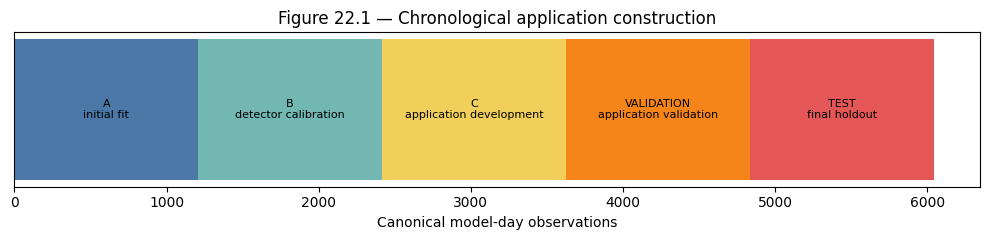

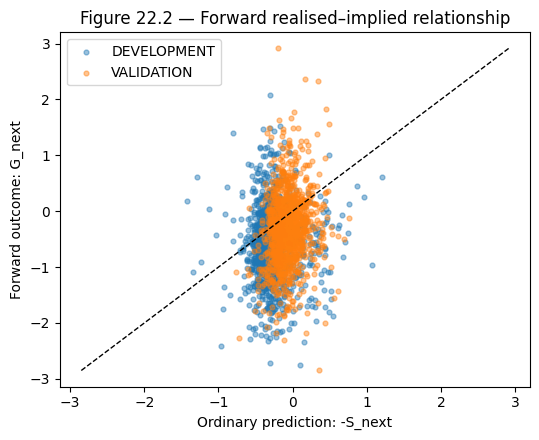

In [13]:
timing_audit = pd.DataFrame(
    [
        ("R_t", "current realised variance", "end of model day t", "state / audit", True),
        ("I_t", "current implied variance", "end of model day t", "forward baseline input", True),
        ("D_t", "realised-implied disagreement", "end of model day t", "hidden-state feature", True),
        ("Z_R_t", "realised abnormality", "end of model day t", "hidden-state feature", True),
        ("Z_I_prev", "prior implied abnormality", "end of model day t", "hidden-state feature", True),
        ("S_next", "ordinary forward state", "end of model day t", "baseline", True),
        ("R_next", "future realised variance", "after model day t+1", "target input", False),
        ("G_next", "forward realised-implied gap", "after model day t+1", "target", False),
        ("C_next", "ordinary-model correction", "after model day t+1", "target", False),
    ],
    columns=[
        "variable", "meaning", "information_timestamp", "role",
        "allowed_at_decision_time",
    ],
)
display(timing_audit)

summary_rows = []
for stage_name, group in application_panel.groupby("application_stage", sort=False):
    labels = group["hidden_type"].value_counts()
    scored_count = int(group["state_scored"].sum())
    not_scored_count = int((~group["state_scored"]).sum())
    none_count = int(labels.get("NONE", 0))
    realised_count = int(labels.get("REALISED_ONLY", 0))
    implied_count = int(labels.get("IMPLIED_ONLY", 0))
    hidden_count = int(group["is_hidden"].sum())
    target_count = (
        "LOCKED"
        if stage_name == "TEST" and not UNLOCK_TEST_TARGETS
        else int(group["target_complete"].sum())
    )
    summary_rows.append(
        (
            stage_name, group.model_day.min(), group.model_day.max(), len(group),
            scored_count, not_scored_count, none_count, realised_count,
            implied_count, hidden_count, target_count,
        )
    )
stage_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "application_stage", "start", "end", "rows", "scored_states",
        "not_scored_states", "none", "realised_only", "implied_only",
        "hidden_states", "target_available_count",
    ],
)
display(stage_summary)

fig, ax = plt.subplots(figsize=(10, 2.5))
left = 0
colors = ["#4c78a8", "#72b7b2", "#f2cf5b", "#f58518", "#e45756"]
figure_labels = {
    "A": "A\ninitial fit",
    "B": "B\ndetector calibration",
    "C": "C\napplication development",
    "VALIDATION": "VALIDATION\napplication validation",
    "TEST": "TEST\nfinal holdout",
}
for row, color in zip(chronology.itertuples(index=False), colors):
    ax.barh(0, row.rows, left=left, color=color)
    ax.text(
        left + row.rows / 2,
        0,
        figure_labels[row.period],
        ha="center",
        va="center",
        fontsize=8,
    )
    left += row.rows
ax.set(
    yticks=[],
    xlabel="Canonical model-day observations",
    title="Figure 22.1 — Chronological application construction",
)
fig.tight_layout()
fig.savefig(FIGURES / "22_figure_application_chronology.png", dpi=180)
plt.show()

plot_rows = application_panel.loc[
    application_panel.application_stage.isin(["DEVELOPMENT", "VALIDATION"])
    & application_panel.G_next.notna()
    & application_panel.G_hat_ordinary_next.notna()
]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for stage_name, group in plot_rows.groupby("application_stage"):
    ax.scatter(
        group.G_hat_ordinary_next,
        group.G_next,
        s=12,
        alpha=.45,
        label=stage_name,
    )
limits = [
    min(plot_rows.G_hat_ordinary_next.min(), plot_rows.G_next.min()),
    max(plot_rows.G_hat_ordinary_next.max(), plot_rows.G_next.max()),
]
ax.plot(limits, limits, "k--", lw=1)
ax.set(
    xlabel="Ordinary prediction: -S_next",
    ylabel="Forward outcome: G_next",
    title="Figure 22.2 — Forward realised–implied relationship",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "22_figure_forward_ordinary_relationship.png", dpi=180)
plt.show()

# 9. Closure and exports

All chronology, state, target-lock and N21 handoff assertions pass before atomic production exports.

In [14]:
assert not UNLOCK_TEST_TARGETS
assert tuple(chronology.rows) == (1208, 1209, 1209, 1209, 1209)
assert application_panel.model_day.is_unique
assert application_panel.model_day.is_monotonic_increasing
assert set(application_panel.application_stage) == {
    "DEVELOPMENT", "VALIDATION", "TEST",
}
assert C_state.model_day.isin(C).all()
assert C_state.implied_reference_model_day.isin(C).all()
assert V_state.model_day.isin(V).all()
assert V_state.implied_reference_model_day.isin(V).all()
assert application_panel.is_known_primary_event_pair.dtype == bool

for stage_name, group in application_panel.groupby("application_stage"):
    scored = int(group.state_scored.sum())
    not_scored = int((~group.state_scored).sum())
    none = int(group.hidden_type.eq("NONE").sum())
    realised = int(group.hidden_type.eq("REALISED_ONLY").sum())
    implied = int(group.hidden_type.eq("IMPLIED_ONLY").sum())
    assert len(group) == scored + not_scored
    assert scored == none + realised + implied

historical = application_panel.application_stage.isin(
    ["DEVELOPMENT", "VALIDATION"]
)
assert application_panel.loc[
    historical & ~application_panel.state_scored,
    "hidden_type",
].eq("NOT_SCORED").all()
assert application_panel.loc[
    historical & application_panel.state_scored,
    "hidden_type",
].ne("NOT_SCORED").all()
assert application_panel.loc[
    ~application_panel.state_scored,
    "hidden_type",
].eq("NOT_SCORED").all()
assert application_panel.loc[
    application_panel.is_hidden,
    "hidden_type",
].isin(["REALISED_ONLY", "IMPLIED_ONLY"]).all()

unlocked = application_panel.G_next.notna()
assert application_panel.loc[
    unlocked, "application_stage"
].eq(application_panel.loc[unlocked, "target_stage"]).all()
assert not (
    application_panel.loc[unlocked, "application_stage"].eq("VALIDATION")
    & application_panel.loc[unlocked, "target_source_split"].eq("test")
).any()
assert not (
    application_panel.loc[unlocked, "application_stage"].eq("DEVELOPMENT")
    & application_panel.loc[unlocked, "target_source_split"].eq("validation")
).any()
last_validation = application_panel.loc[
    application_panel.application_stage.eq("VALIDATION"),
    ["model_day", "G_next", "C_next"],
].iloc[-1]
assert last_validation.model_day == V.max()
assert pd.isna(last_validation.G_next)
assert pd.isna(last_validation.C_next)

test_rows = application_panel.application_stage.eq("TEST")
assert application_panel.loc[test_rows, "G_next"].isna().all()
assert application_panel.loc[test_rows, "C_next"].isna().all()
assert application_panel.loc[test_rows, "test_target_locked"].all()
assert test_unlock_self_check.iloc[0].all()

values = mp.set_index("model_day").loc[
    application_panel.loc[unlocked, "next_model_day"],
    "R",
].to_numpy()
assert np.allclose(
    application_panel.loc[unlocked, "G_next"],
    np.log(values / application_panel.loc[unlocked, "I_t"].to_numpy()),
    rtol=1e-12,
    atol=1e-12,
)
correction = application_panel.C_next.notna()
assert np.allclose(
    application_panel.loc[correction, "C_next"],
    application_panel.loc[correction, "G_next"]
    + application_panel.loc[correction, "S_next"],
    rtol=1e-12,
    atol=1e-12,
)
signals = application_panel.S_next.notna()
assert np.allclose(
    application_panel.loc[signals, "G_hat_ordinary_next"],
    -application_panel.loc[signals, "S_next"],
    rtol=0,
    atol=0,
)
assert signal_equivalence_audit.loc[0, "coverage_equivalent"]
assert signal_equivalence_audit.loc[0, "support_count_equivalent"]
assert signal_equivalence_audit.loc[0, "signal_values_equivalent"]

test_handoff = application_panel.loc[
    test_rows
    & application_panel.n21_candidate_type.isin(
        ["REALISED_ONLY", "IMPLIED_ONLY"]
    ),
    ["model_day", "n21_candidate_type"],
]
expected = {
    (pd.Timestamp(day).normalize(), str(kind))
    for day, kind in zip(
        candidates.realised_model_day,
        candidates.candidate_type,
    )
}
actual = {
    (pd.Timestamp(day).normalize(), str(kind))
    for day, kind in zip(
        test_handoff.model_day,
        test_handoff.n21_candidate_type,
    )
}
assert actual == expected
assert len(test_handoff) == 14
assert int(test_handoff.n21_candidate_type.eq("REALISED_ONLY").sum()) == 4
assert int(test_handoff.n21_candidate_type.eq("IMPLIED_ONLY").sum()) == 10
assert len(episodes) == 14

ready_for_application_state_export = True
print("N22 closure: PASS")

N22 closure: PASS


In [15]:
if not ready_for_application_state_export: raise RuntimeError("Closure must pass before N22 exports")
metadata=pd.DataFrame([{"notebook":"22_application_causal_state_and_forward_economic_target.ipynb","source_pipeline":"Frozen N14–N21","frozen_n19_specifications":" | ".join(f"{target}/{model}:{'|'.join(item['parent_blocks'])},L={item['lag_order']}" for (target,model),item in sorted(SELECTED.items())),"n20_semantics":"ordinary observed / ordinary event-unaware forecast; no eventless masking","historical_chronology":"A(1208)->B(1209)->C(1209)->VALIDATION(1209)->TEST(1209)","active_threshold":ACTIVE_THRESHOLD,"minimum_model_support":MIN_MODEL_SUPPORT,"test_targets_locked":not UNLOCK_TEST_TARGETS,"models_reselected":False,"hyperparameters_reselected":False,"equation_5_used":False,"bloomberg_alignment":BLOOMBERG_ALIGNMENT,"downstream_feature_families":"ordinary={S_next}; hidden={D_t,Z_R_t,Z_I_prev}; combined={S_next,D_t,Z_R_t,Z_I_prev}"}])
exports={"22_application_causal_state_panel.csv":application_panel,"22_application_stage_summary.csv":stage_summary,"22_application_timing_audit.csv":timing_audit,"22_run_metadata.csv":metadata}
temporary={}
for name,frame in exports.items():
    temporary[name]=PROCESSED/f".{name}.tmp"; frame.to_csv(temporary[name],index=False)
for name,temp in temporary.items(): temp.replace(PROCESSED/name)
print("N22 atomic exports written:",", ".join(exports))

N22 atomic exports written: 22_application_causal_state_panel.csv, 22_application_stage_summary.csv, 22_application_timing_audit.csv, 22_run_metadata.csv
